In [ ]:
import pandas as pd
import glob

files = glob.glob("/project2/ll_774_951/uk_ru/Instagram_Uk_ru/*.pkl")

dfs = []
for f in sorted(files):
    print('reading ', f)
    dfs.append(pd.read_pickle(f))

dfs = [pd.DataFrame(x) for x in dfs]
df = pd.concat(dfs, ignore_index=True)
del dfs  # free memory

# The pattern without the JS-style delimiters
pattern = r'(?:^|(?<=\s))@([A-Za-z0-9_](?:(?:[A-Za-z0-9_]|(?:\.(?!\.))){0,28}(?:[A-Za-z0-9_]))?)'

# Extract all matches into a new DataFrame
df['mentions'] = df['description'].str.extractall(pattern).groupby(level=0).agg(list)

# The Python/Pandas compatible pattern
hashtag_pattern = r'(?:^|(?<=\s))#([A-Za-z_][A-Za-z0-9_]{0,29})'

# Implementation
df['hashtags'] = df['description'].str.extractall(hashtag_pattern).groupby(level=0).agg(list)

df['handle'] = df.account.str['handle']

df.to_parquet("instagram_uk_ru.parquet", index=False)

In [222]:
import wandb                                                                                                                                                                                                                             
import matplotlib.pyplot as plt
                                                                                                                                                                                                                                        
ENTITY = "eibl-usc"                                       
PROJECT = "graph-clip"

api = wandb.Api()
runs = list(api.runs(f"{ENTITY}/{PROJECT}"))

In [ ]:
# Built-in method — returns a DataFrame of config, summary metrics, etc.
df = pd.DataFrame([
    {
        "name": run.name,
        "state": run.state,
        **run.config,
        **run.summary._json_dict,
    }
    for run in runs
])

In [112]:
df = df.drop(columns=[c for c in df.columns if 'gradients' in c])
df["created_at"] = [run.created_at for run in runs]
df['n_way'] = df.params.str['n_way']
df['n_shots'] = df.params.str['n_shots']
df['n_qry'] = df.params.str['n_query']
df.sort_values('created_at', ascending=False)[:3]

,name,state,trainer_fs,_runtime,_wandb,wandb_url,params,num_params,_step,_timestamp,...,valid_loss,best_step,best_test_acc,final_validation_acc,test_acc_on_best_val,created_at,n_way,n_shot,n_qry,n_shots
148,pretrain_instagram_nm_11_03_2026_15_42_26,running,True,1953.338661,{'runtime': 1953},https://wandb.ai/eibl-usc/graph-clip/runs/x8ar...,"{'root': 'data/graphs/ukr_ru/instagram', 'seed...",1771586.0,4146.0,1.773271e+09,...,0.290051,NaN,NaN,NaN,NaN,2026-03-11T22:42:51Z,10.0,NaN,10.0,4.0
147,pretrain_instagram_nm_11_03_2026_14_44_15,crashed,True,5296.530361,{'runtime': 5296},https://wandb.ai/eibl-usc/graph-clip/runs/nwcv...,"{'root': 'data/graphs/ukr_ru/instagram', 'seed...",1771586.0,5999.0,1.773271e+09,...,0.222699,NaN,NaN,NaN,NaN,2026-03-11T21:44:32Z,5.0,NaN,24.0,5.0
146,pretrain_instagram_nm_11_03_2026_14_09_51,crashed,True,1757.691244,{'runtime': 1757},https://wandb.ai/eibl-usc/graph-clip/runs/v0oi...,"{'root': 'data/graphs/ukr_ru/instagram', 'seed...",1771586.0,4806.0,1.773265e+09,...,0.193453,NaN,NaN,NaN,NaN,2026-03-11T21:10:09Z,3.0,NaN,24.0,3.0


shot=1  acc=0.3343 ± 0.0235  (ig_overperformer_zeroshot_shot1_10_03_2026_17_44_43)
shot=2  acc=0.3355 ± 0.0237  (ig_overperformer_zeroshot_shot2_10_03_2026_17_44_44)
shot=3  acc=0.3351 ± 0.0237  (ig_overperformer_zeroshot_shot3_10_03_2026_17_45_39)
shot=5  acc=0.3376 ± 0.0231  (ig_overperformer_zeroshot_shot5_10_03_2026_17_44_47)
shot=10  acc=0.3380 ± 0.0232  (ig_overperformer_zeroshot_shot10_10_03_2026_17_44_39)


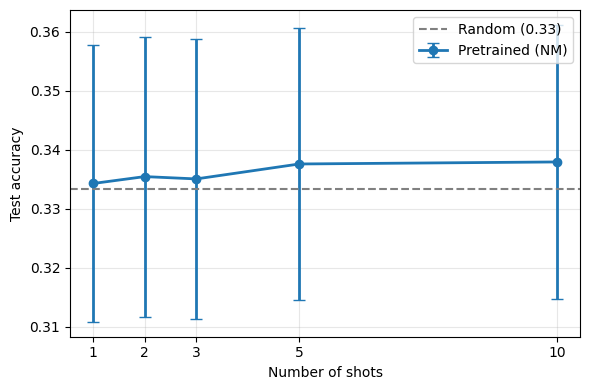

In [ ]:
PREFIX = "ig_overperformer_zeroshot_shot"
SHOTS = [1, 2, 3, 5, 10]
RANDOM_BASELINE = 1/3

accs, stds = [], []
for shot in SHOTS:
    run = next(r for r in runs if r.name.startswith(f"{PREFIX}{shot}_"))
    accs.append(run.summary.get("start_test_acc"))
    stds.append(run.summary.get("start_test_acc_std", 0))
    print(f"shot={shot}  acc={accs[-1]:.4f} ± {stds[-1]:.4f}  ({run.name})")

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(SHOTS, accs, yerr=stds, marker="o", linewidth=2, capsize=4, label="Pretrained (NM)")
ax.axhline(RANDOM_BASELINE, color="gray", linestyle="--", linewidth=1.5, label="Random (0.33)")
ax.set_xlabel("Number of shots")
ax.set_ylabel("Test accuracy")
ax.set_xticks(SHOTS)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
[r for r in runs if r.name == 'eval_pseudo_rep_dem_scratch_2way_1shot_08_03_2026_20_04_14'][0].summary

{'_runtime': 10.663530335, '_step': 0, '_timestamp': 1773025476.5749395, '_wandb': {'runtime': 10}, 'num_params': 1297474, 'start_test_acc': 0.50153, 'start_test_acc_std': 0.03834200177351204, 'wandb_url': 'https://wandb.ai/eibl-usc/graph-clip/runs/asos9ve2'}

In [159]:
trained_on = {
    'scratch': [
        'eval_pseudo_rep_dem_scratch_2way_20shot_08_03_2026_20_06_31',
        'eval_pseudo_rep_dem_scratch_2way_10shot_08_03_2026_20_05_58',
        'eval_pseudo_rep_dem_scratch_2way_5shot_08_03_2026_20_05_22',
        'eval_pseudo_rep_dem_scratch_2way_3shot_08_03_2026_20_04_43',
        'eval_pseudo_rep_dem_scratch_2way_1shot_08_03_2026_20_04_14',
    ],
    'pretrained': [
        'eval_pseudo_rep_dem_2way_1shot_08_03_2026_21_41_11',
        'eval_pseudo_rep_dem_2way_3shot_08_03_2026_21_42_25',
        'eval_pseudo_rep_dem_2way_5shot_08_03_2026_21_42_54',
        'eval_pseudo_rep_dem_2way_10shot_08_03_2026_21_43_25',
        'eval_pseudo_rep_dem_2way_20shot_08_03_2026_21_43_57',
    ],
    'finetuned': [
        'eval_finetune_pseudo_rep_dem_2way_1shot_08_03_2026_22_10_44',
        'eval_finetune_pseudo_rep_dem_2way_3shot_08_03_2026_22_11_46',
        'eval_finetune_pseudo_rep_dem_2way_5shot_08_03_2026_22_12_14',
        'eval_finetune_pseudo_rep_dem_2way_10shot_08_03_2026_22_12_43',
        'eval_finetune_pseudo_rep_dem_2way_20shot_08_03_2026_22_13_15',
    ],
}

pdf = []
for k, v in trained_on.items():
    tdf = df[df.name.isin(v)]
    tdf['setting'] = k
    pdf.append(tdf)
    
pdf = pd.concat(pdf)
pdf['acc'] = pdf.start_test_acc

/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_691/956819394.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tdf['setting'] = k
/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_691/956819394.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tdf['setting'] = k
/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_691/956819394.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value in

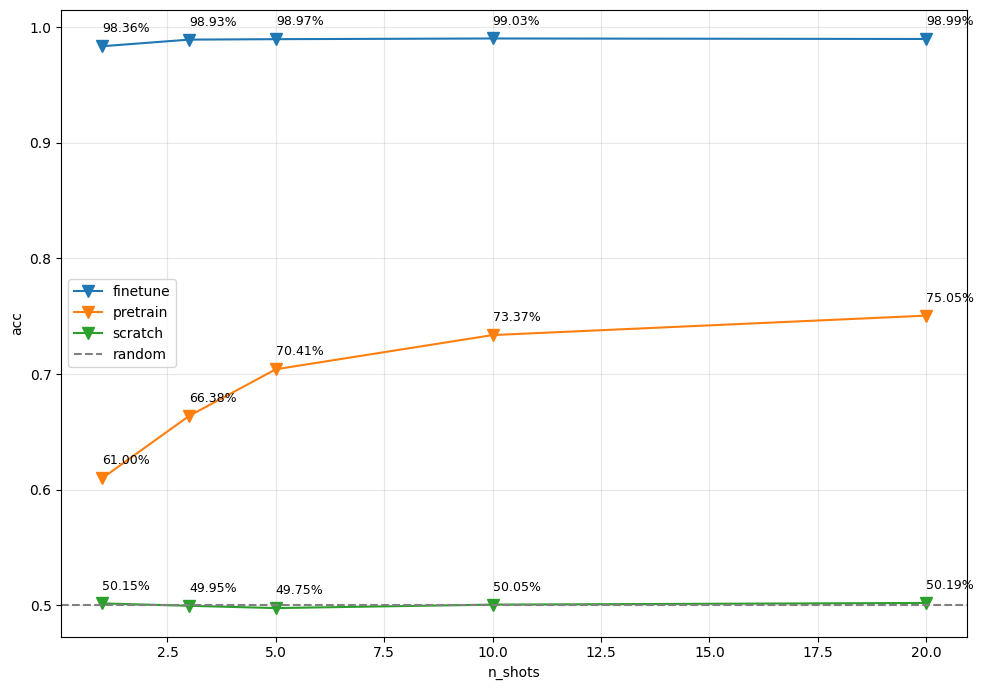

In [161]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 7))

n_shots = [1, 3, 5, 10, 20]

for setting, marker, color, label in [
    ('finetuned', 'v', 'tab:blue', 'finetune'),
    ('pretrained', 'v', 'tab:orange', 'pretrain'),
    ('scratch', 'v', 'tab:green', 'scratch'),
]:
    sub = pdf[pdf.setting == setting].sort_values('n_shots')
    ax.plot(sub.n_shots, sub.acc, marker=marker, label=label, color=color, markersize=8)
    for _, row in sub.iterrows():
        ax.annotate(f"{row.acc*100:.2f}%", (row.n_shots, row.acc),
                     textcoords="offset points", xytext=(0, 10), fontsize=9)

# random baseline
ax.axhline(0.5, color='gray', linestyle='--', label='random')

ax.set_xlabel('n_shots')
ax.set_ylabel('acc')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [200]:
import re                                                                               
import pandas as pd                                                                     
import matplotlib.pyplot as plt                                                         
import matplotlib.cm as cm                                
import wandb                                                                            
                                                        
MODELS = [
    "pretrain_instagram_nm_11_03_2026_15_42_26",
    "pretrain_instagram_nm_11_03_2026_14_44_15",
    "pretrain_instagram_nm_11_03_2026_14_09_51",
]
MODEL_SHORT = {
    "pretrain_instagram_nm_11_03_2026_15_42_26": "trained_on_10shot_10way_10qry",
    "pretrain_instagram_nm_11_03_2026_14_44_15": "trained_on_5shot_5way_24qry",
    "pretrain_instagram_nm_11_03_2026_14_09_51": "trained_on_3shot_3way_24qry",
}

api = wandb.Api()

In [223]:
import re

runs = [run for run in runs if re.findall(r"^eval_overperformer_pretrain_instagram_nm_11_03_2026" ,run.name)][::-1]

In [ ]:
records = []
for run in runs:
    m = re.search(r"_(\d+)shot_(\d+)way", run.name)
    if not m:
        continue
    model_key = next((k for k in MODELS if k in run.name), None)
    if model_key is None:
        continue
    acc = run.summary.get("test_acc")
    start_acc = run.summary.get("start_test_acc")
    if acc is None:
        continue
    records.append({
        "model": MODEL_SHORT[model_key],
        "shot":  int(m.group(1)),
        "way":   int(m.group(2)),
        "acc":   acc,
        "std":   run.summary.get("test_acc_std", 0),
        "start_acc":   start_acc,
        "start_std":   run.summary.get("start_test_acc_std", 0),
    })
    
df = pd.DataFrame(records)
df.sort_values(["model", "way", "shot"])

,model,shot,way,acc,std,start_acc,start_std
18,trained_on_10shot_10way_10qry,1,2,0.497417,0.042282,0.500992,0.032633
14,trained_on_10shot_10way_10qry,3,2,0.558925,0.052358,0.500933,0.031053
12,trained_on_10shot_10way_10qry,5,2,0.669083,0.053458,0.503625,0.032417
11,trained_on_10shot_10way_10qry,10,2,0.733942,0.048954,0.506600,0.033812
9,trained_on_10shot_10way_10qry,1,3,0.350211,0.031744,0.336511,0.024815
5,trained_on_10shot_10way_10qry,3,3,0.464950,0.037901,0.337156,0.025451
13,trained_on_10shot_10way_10qry,5,3,0.561689,0.031634,0.339578,0.024833
20,trained_on_10shot_10way_10qry,10,3,0.688328,0.025443,0.338711,0.025163
10,trained_on_3shot_3way_24qry,1,2,0.502508,0.022690,0.502833,0.030125
6,trained_on_3shot_3way_24qry,3,2,0.554658,0.052552,0.501725,0.029538


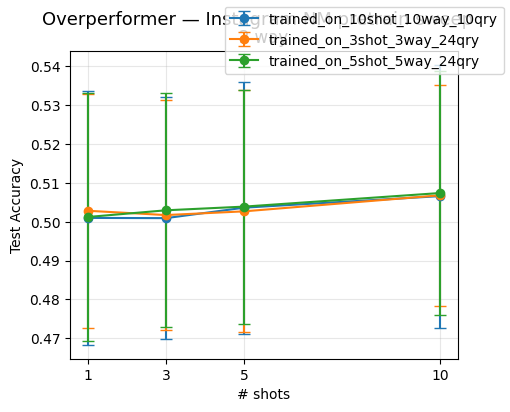

In [233]:
df = df[df.way.eq(2)]
ways   = sorted(df["way"].unique())
models = sorted(df["model"].unique())
shots  = sorted(df["shot"].unique())
colors = {m: c for m, c in zip(models, plt.cm.tab10.colors)}

fig, axes = plt.subplots(1, len(ways), figsize=(5 * len(ways), 4), sharey=True)

if not isinstance(axes, np.ndarray):
    axes = np.array([axes]) 
      
for ax, way in zip(axes, ways):
    for model in models:
        sub = df[(df["way"] == way) & (df["model"] == model)].sort_values("shot")
        if sub.empty:
            continue
        ax.errorbar(sub["shot"], sub["start_acc"], yerr=sub["start_std"], marker="o", label=model,
            color=colors[model], capsize=4)
    ax.set_title(f"{way}-way")
    ax.set_xlabel("# shots")
    ax.set_xticks(shots)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Test Accuracy")
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper right")
fig.suptitle("Overperformer — Instagram NM pretrain sweep", fontsize=13)
# fig.tight_layout()
plt.show()

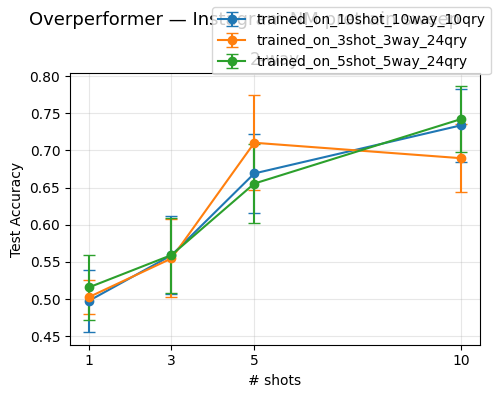

In [234]:
# ways   = sorted(df["way"].unique())
ways   = sorted(df["way"].unique())
models = sorted(df["model"].unique())
shots  = sorted(df["shot"].unique())
colors = {m: c for m, c in zip(models, plt.cm.tab10.colors)}

fig, axes = plt.subplots(1, len(ways), figsize=(5 * len(ways), 4), sharey=True)

if not isinstance(axes, np.ndarray):
    axes = np.array([axes]) 
    
for ax, way in zip(axes, ways):
    for model in models:
        sub = df[(df["way"] == way) & (df["model"] == model)].sort_values("shot")
        if sub.empty:
            continue
        ax.errorbar(sub["shot"], sub["acc"], yerr=sub["std"], marker="o", label=model,
color=colors[model], capsize=4)
    ax.set_title(f"{way}-way")
    ax.set_xlabel("# shots")
    ax.set_xticks(shots)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Test Accuracy")
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper right")
fig.suptitle("Overperformer — Instagram NM pretrain sweep", fontsize=13)
fig.tight_layout()
plt.show()